# 01 — Graph basics (Course topic L2)

**Semiconductor Supply Chain — Network Analysis**

This notebook establishes the analysis harness used by every later notebook:
it loads the graph mirror, inventories node/edge types, builds the canonical
**supply network** projection, and reports basic structural properties.

> **Hypothesis under test (whole project):** the semiconductor supply chain is
> an ultra-fragile *scale-free* network where removing 3–5 hub nodes (TSMC,
> ASML, Shin-Etsu, Air Products, an ARM licensor) fragments the giant
> connected component.

Data provenance: every SUPPLIES/MANUFACTURES edge carries `source_url` +
`source_date` (see `data/sources.csv`).

In [1]:
import sys
from pathlib import Path

# Locate project root (works whether cwd is project root or notebooks/)
ROOT = Path.cwd()
while not (ROOT / 'scripts' / 'analysis.py').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'scripts'))

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

import analysis

G = analysis.full_graph()
print(f'Loaded mirror: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges '
      f'({type(G).__name__})')

Loaded mirror: 182 nodes, 1615 edges (MultiDiGraph)


## 1. Inventory — node and relationship types

A heterogeneous (multi-layer) graph: Company, Country and Product nodes, with
six relationship types.

In [2]:
node_counts = pd.Series(
    [d.get('label') for _, d in G.nodes(data=True)]
).value_counts().rename_axis('node_label').rename('count')

edge_counts = pd.Series(
    [d.get('rel_type') for _, _, d in G.edges(data=True)]
).value_counts().rename_axis('rel_type').rename('count')

print('Nodes by label:'); display(node_counts.to_frame())
print('Edges by type:');  display(edge_counts.to_frame())

Nodes by label:


,count
node_label,
Company,108
Product,61
Country,13


Edges by type:


,count
rel_type,
SUPPLIES,1256
MANUFACTURES,172
LOCATED_IN,108
COMPETES_WITH,45
DEPENDS_ON,34


## 2. The supply network projection

The hypothesis is about **who supplies whom**, so the core analysis object is
the directed Company-only graph of `SUPPLIES` edges. `COMPETES_WITH`,
`LOCATED_IN` and the Product `DEPENDS_ON` layer are analysed separately later.

In [3]:
D = analysis.company_supply_digraph(G)   # directed
U = D.to_undirected(as_view=False)       # undirected view for connectivity

n, m = D.number_of_nodes(), D.number_of_edges()
props = {
    'companies (nodes)': n,
    'SUPPLIES edges': m,
    'density': round(nx.density(D), 4),
    'avg in/out-degree': round(m / n, 2),
    'weakly connected': nx.is_weakly_connected(D),
    'weak components': nx.number_weakly_connected_components(D),
    'strongly connected comps': nx.number_strongly_connected_components(D),
    'reciprocity': round(nx.reciprocity(D), 4),
}
pd.Series(props, name='value').to_frame()

,value
companies (nodes),108
SUPPLIES edges,1256
density,0.1087
avg in/out-degree,11.63
weakly connected,True
weak components,1
strongly connected comps,108
reciprocity,0.0


In [4]:
# Giant (weakly) connected component — the structure resilience will attack
GCC = analysis.giant_component(D)
print(f'Giant component covers {GCC.number_of_nodes()}/{n} companies '
      f'({GCC.number_of_nodes()/n:.0%}) and {GCC.number_of_edges()} edges.')

# Average shortest path length + clustering (on the undirected GCC) — baseline
U_gcc = GCC.to_undirected()
print(f'Undirected GCC: avg path length = {nx.average_shortest_path_length(U_gcc):.3f}, '
      f'clustering = {nx.average_clustering(U_gcc):.3f}, '
      f'diameter = {nx.diameter(U_gcc)}')

Giant component covers 108/108 companies (100%) and 1256 edges.
Undirected GCC: avg path length = 1.991, clustering = 0.086, diameter = 4


## 3. Degree analysis — first look at the hubs

In a directed supply graph: **in-degree** = number of distinct suppliers a
company draws from; **out-degree** = number of distinct companies it supplies.
High out-degree marks upstream chokepoints (equipment/materials); high
in-degree marks assembly-heavy downstream firms.

In [5]:
deg = pd.DataFrame({
    'type': pd.Series(dict(D.nodes(data='type'))),
    'in_degree': pd.Series(dict(D.in_degree())),
    'out_degree': pd.Series(dict(D.out_degree())),
})
deg['total_degree'] = deg['in_degree'] + deg['out_degree']
deg = deg.sort_values('total_degree', ascending=False)
print('Top 10 companies by total degree:')
display(deg.head(10))
print('Highest out-degree (upstream chokepoints):')
display(deg.sort_values('out_degree', ascending=False)[['type', 'out_degree']].head(6))

Top 10 companies by total degree:


,type,in_degree,out_degree,total_degree
TSMC,fab,44,17,61
NXP,IDM,43,2,45
Samsung Foundry,fab,39,5,44
Intel,IDM,42,0,42
STMicroelectronics,IDM,40,2,42
Renesas,IDM,39,2,41
Infineon,IDM,39,2,41
Analog Devices,IDM,38,2,40
Texas Instruments,IDM,38,2,40
onsemi,IDM,37,2,39


Highest out-degree (upstream chokepoints):


,type,out_degree
Synopsys,EDA,35
Cadence,EDA,35
Siemens EDA,EDA,35
KLA,equipment,27
Onto Innovation,equipment,27
Fujifilm,materials,27


saved C:\Users\Max\Desktop\project\reports\figures\01_degree_overview.png


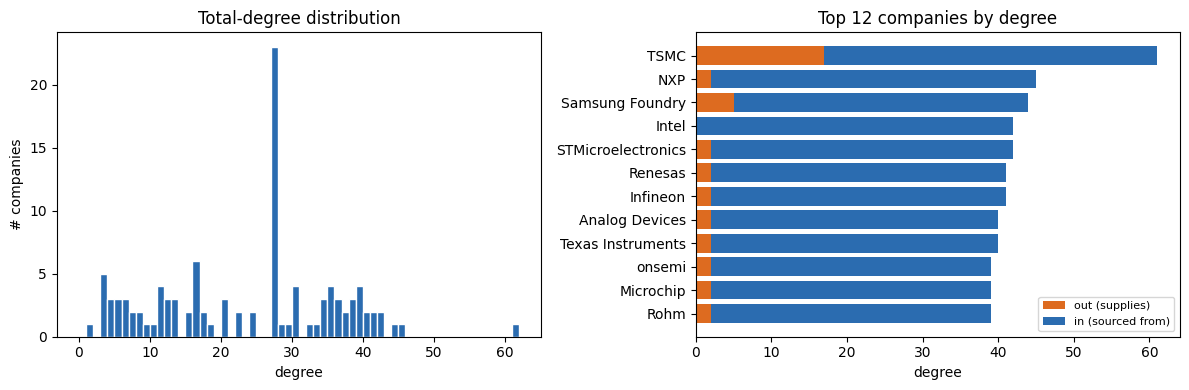

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) degree distribution
axes[0].hist(deg['total_degree'], bins=range(0, int(deg['total_degree'].max()) + 2),
             color='#2b6cb0', edgecolor='white')
axes[0].set(title='Total-degree distribution', xlabel='degree', ylabel='# companies')

# (b) top-12 companies bar, coloured by tier
top = deg.head(12).iloc[::-1]
axes[1].barh(top.index, top['out_degree'], label='out (supplies)', color='#dd6b20')
axes[1].barh(top.index, top['in_degree'], left=top['out_degree'],
             label='in (sourced from)', color='#2b6cb0')
axes[1].set(title='Top 12 companies by degree', xlabel='degree')
axes[1].legend(loc='lower right', fontsize=8)

fig.tight_layout()
out = analysis.FIGURES / '01_degree_overview.png'
fig.savefig(out, dpi=130, bbox_inches='tight')
print('saved', out)
plt.show()

## 4. Takeaways

- The supply network is a single weakly-connected component — no isolated
  firms — which is the precondition for the fragmentation experiment in
  notebook `07_resilience`.
- Degree is highly **skewed**: a few firms (TSMC, and the upstream
  equipment/materials suppliers ASML, Shin-Etsu, Applied Materials) dominate,
  while most companies have low degree — the visual signature of a scale-free
  network, formally tested in `06_scale_free`.
- Out-degree pinpoints **upstream chokepoints** (equipment & materials sell to
  every fab); in-degree marks downstream integrators. This split foreshadows
  the betweenness/articulation-point findings in `02_centrality` and
  `03_connectivity`.

**Next:** `02_centrality.ipynb` — degree, betweenness, closeness, eigenvector
centrality to identify the true bottlenecks.